---
<img src=https://audiovisuales.icesi.edu.co/assets/custom/images/ICESI_logo_prin_descriptor_RGB_POSITIVO_0924.jpg width=300>

# **<big><big>Algoritmos y Programación III</big></big>**
**Proyecto final — Clasificación de calidad de frutas**

---

- **Martinez Vasquez Luna Catalina - A00401964**<br>
- **Mosquera Daza Renzo Fernando - A00401681**<br>
- **Tobar Gómez Valentina - A00401749**<br>

---

# Notebook 01 — EDA y comprensión de datos


## 1. Importación de librerías

Se cargan las librerías necesarias para recorrer carpetas, abrir imágenes, calcular resúmenes y guardar evidencias del EDA.

In [1]:
from pathlib import Path
import hashlib
import json
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd
from PIL import Image, ImageOps, UnidentifiedImageError
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 90)
pd.set_option("display.max_rows", 90)
pd.set_option("display.max_colwidth", 180)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
RANDOM_STATE = 42

## 2. Rutas del proyecto

Se usan únicamente las rutas conocidas del árbol del proyecto. Las imágenes públicas se leen desde `data/raw/fruit_quality` y las imágenes propias desde `data/raw/propias`.

In [2]:
PROJECT_ROOT = Path.cwd().parent
RAW_ROOT_DIR = PROJECT_ROOT / "data" / "raw"
RAW_DIR = RAW_ROOT_DIR / "fruit_quality"
PROPIAS_DIR = RAW_ROOT_DIR / "propias"
ANNOTATIONS_DIR = PROJECT_ROOT / "data" / "annotations"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"
TARGET_IMAGE_SIZE = 128

for directory in [RAW_DIR, PROPIAS_DIR, ANNOTATIONS_DIR, FIGURES_DIR, TABLES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Proyecto:", PROJECT_ROOT)
print("Datos públicos:", RAW_DIR)
print("Datos propios:", PROPIAS_DIR)
print("Anotaciones:", ANNOTATIONS_DIR)
print("Figuras:", FIGURES_DIR)
print("Tablas:", TABLES_DIR)
print("Tamaño para el Notebook 02:", f"{TARGET_IMAGE_SIZE}x{TARGET_IMAGE_SIZE}")

Proyecto: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3
Datos públicos: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\data\raw\fruit_quality
Datos propios: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\data\raw\propias
Anotaciones: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\data\annotations
Figuras: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\results\figures
Tablas: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\results\tables
Tamaño para el Notebook 02: 128x128


## 3. Definición de etiquetas y normalización

El dataset puede llegar con nombres distintos de carpetas. Aquí se unifican las etiquetas de calidad, fuente, producto y tamaño para evitar errores por mayúsculas, espacios, tildes o cambios como `Qualt` a `Quality`.

In [3]:
SOURCES = ["public", "own"]
QUALITY_LABELS = ["bad", "regular", "good"]
QUALITY_LABELS_ES = {"bad": "mala", "regular": "regular", "good": "buena"}
SIZE_LABELS = ["small", "medium", "large"]
SIZE_LABELS_ES = {"small": "pequeño", "medium": "mediano", "large": "grande"}
PRODUCT_TYPES = ["apple", "banana", "guava", "lemon", "lime", "orange", "pomegranate", "tomato", "potato", "pepper", "carrot", "onion", "unknown"]
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

SOURCE_ALIASES = {
    "public": "public",
    "publica": "public",
    "publicas": "public",
    "publico": "public",
    "publicos": "public",
    "dataset": "public",
    "kaggle": "public",
    "train": "public",
    "test": "public",
    "validation": "public",
    "val": "public",
    "own": "own",
    "propia": "own",
    "propias": "own",
    "propio": "own",
    "propios": "own",
    "private": "own",
    "personal": "own"
}

QUALITY_ALIASES = {
    "bad": "bad",
    "bad_quality": "bad",
    "bad_qualt": "bad",
    "bad_quality_fruit": "bad",
    "bad_quality_fruits": "bad",
    "bad_qualt_fruit": "bad",
    "bad_qualt_fruits": "bad",
    "mala": "bad",
    "malas": "bad",
    "malo": "bad",
    "malos": "bad",
    "rotten": "bad",
    "damaged": "bad",
    "poor": "bad",
    "regular": "regular",
    "regular_quality": "regular",
    "regular_qualt": "regular",
    "regular_quality_fruit": "regular",
    "regular_quality_fruits": "regular",
    "regular_qualt_fruit": "regular",
    "regular_qualt_fruits": "regular",
    "medium_quality": "regular",
    "normal": "regular",
    "good": "good",
    "good_quality": "good",
    "good_qualt": "good",
    "good_quality_fruit": "good",
    "good_quality_fruits": "good",
    "good_qualt_fruit": "good",
    "good_qualt_fruits": "good",
    "buena": "good",
    "buenas": "good",
    "bueno": "good",
    "buenos": "good",
    "fresh": "good",
    "healthy": "good"
}

SIZE_ALIASES = {
    "small": "small",
    "pequena": "small",
    "pequeno": "small",
    "pequeña": "small",
    "pequeño": "small",
    "chica": "small",
    "chico": "small",
    "medium": "medium",
    "mediana": "medium",
    "mediano": "medium",
    "regular_size": "medium",
    "large": "large",
    "grande": "large",
    "grandes": "large"
}

PRODUCT_ALIASES = {
    "apple": "apple",
    "apples": "apple",
    "manzana": "apple",
    "manzanas": "apple",
    "banana": "banana",
    "bananas": "banana",
    "platano": "banana",
    "platanos": "banana",
    "guava": "guava",
    "guavas": "guava",
    "guayaba": "guava",
    "guayabas": "guava",
    "lemon": "lemon",
    "lemons": "lemon",
    "limon": "lemon",
    "limones": "lemon",
    "lime": "lime",
    "limes": "lime",
    "orange": "orange",
    "oranges": "orange",
    "naranja": "orange",
    "naranjas": "orange",
    "pomegranate": "pomegranate",
    "pomegranates": "pomegranate",
    "granada": "pomegranate",
    "granadas": "pomegranate",
    "tomato": "tomato",
    "tomatoes": "tomato",
    "tomate": "tomato",
    "tomates": "tomato",
    "potato": "potato",
    "potatoes": "potato",
    "papa": "potato",
    "papas": "potato",
    "pepper": "pepper",
    "pimenton": "pepper",
    "pimentones": "pepper",
    "carrot": "carrot",
    "carrots": "carrot",
    "zanahoria": "carrot",
    "zanahorias": "carrot",
    "onion": "onion",
    "onions": "onion",
    "cebolla": "onion",
    "cebollas": "onion"
}

IGNORED_QUALITY_WORDS = {"quality", "qualt", "qualty", "qualit", "fruits", "fruit", "frutas", "fruta", "mixed", "mix", "regular_size"}


def normalize_text(value):
    text = str(value).strip().lower()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(char for char in text if not unicodedata.combining(char))
    text = re.sub(r"[^a-z0-9]+", "_", text)
    text = re.sub(r"_+", "_", text).strip("_")
    return text


def tokens_from_value(value):
    normalized = normalize_text(value)
    parts = [part for part in normalized.split("_") if part]
    combinations = set(parts + [normalized])

    for start in range(len(parts)):
        for end in range(start + 2, min(len(parts), start + 4) + 1):
            combinations.add("_".join(parts[start:end]))

    return combinations


def resolve_from_aliases(value, aliases):
    for token in tokens_from_value(value):
        if token in aliases:
            return aliases[token]
    return None


def resolve_source(parts, default_source):
    for part in parts:
        source = resolve_from_aliases(part, SOURCE_ALIASES)
        if source in SOURCES:
            return source
    return default_source if default_source in SOURCES else "public"


def resolve_quality(parts):
    for part in parts:
        quality = resolve_from_aliases(part, QUALITY_ALIASES)
        if quality in QUALITY_LABELS:
            return quality
    joined = "_".join(normalize_text(part) for part in parts)
    for label in QUALITY_LABELS:
        if label in joined:
            return label
    return None


def resolve_size(parts):
    for part in parts:
        size = resolve_from_aliases(part, SIZE_ALIASES)
        if size in SIZE_LABELS:
            return size
    return ""


def resolve_product(parts):
    for part in parts:
        product = resolve_from_aliases(part, PRODUCT_ALIASES)
        if product in PRODUCT_TYPES:
            return product
    return "unknown"


## 4. Inventario de imágenes

Se revisa todo lo que existe en `data/raw/fruit_quality` y `data/raw/propias`. No se asume una sola estructura rígida: se infieren las etiquetas desde los nombres de carpetas y archivos.

In [4]:
def find_image_files(root):
    if not root.exists():
        return []
    return sorted(path for path in root.rglob("*") if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS and not path.name.startswith("."))


image_sources = [
    {"root": RAW_DIR, "source_default": "public", "root_name": "fruit_quality"},
    {"root": PROPIAS_DIR, "source_default": "own", "root_name": "propias"}
]

inventory_records = []

for item in image_sources:
    files = find_image_files(item["root"])
    inventory_records.append({
        "root_name": item["root_name"],
        "root": item["root"].relative_to(PROJECT_ROOT).as_posix(),
        "source_default": item["source_default"],
        "image_count": len(files)
    })

inventory_df = pd.DataFrame(inventory_records)
inventory_path = TABLES_DIR / "01_folder_inventory.csv"
inventory_df.to_csv(inventory_path, index=False, encoding="utf-8")

display(inventory_df)
print("Inventario guardado en:", inventory_path)

,root_name,root,source_default,image_count
0,fruit_quality,data/raw/fruit_quality,public,0
1,propias,data/raw/propias,own,8836


Inventario guardado en: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\results\tables\01_folder_inventory.csv


## 5. Construcción de `labels.csv`

Cada imagen válida queda representada con fuente, calidad, tipo de producto, tamaño manual si aparece en la ruta, dimensiones y hash. Las imágenes sin calidad reconocible no se usan para modelado y quedan reportadas para revisión.

In [5]:
def image_metadata(image_path):
    with Image.open(image_path) as image:
        image = ImageOps.exif_transpose(image)
        width, height = image.size
        mode = image.mode
    image_hash = hashlib.md5(image_path.read_bytes()).hexdigest()
    return width, height, mode, image_hash


def build_record(image_path, root, source_default):
    relative_parts = image_path.relative_to(root).parts
    inference_parts = list(relative_parts[:-1]) + [image_path.stem]
    source = resolve_source(inference_parts, source_default)
    quality_label = resolve_quality(inference_parts)
    size_label_manual = resolve_size(inference_parts)
    product_type = resolve_product(inference_parts)

    if quality_label is None:
        return None, "missing_quality"

    width, height, mode, image_hash = image_metadata(image_path)

    return {
        "image_id": f"img_{image_hash[:12]}",
        "source": source,
        "quality_label": quality_label,
        "quality_label_es": QUALITY_LABELS_ES[quality_label],
        "fruit_type": product_type,
        "product_type": product_type,
        "size_label_manual": size_label_manual,
        "relative_path": image_path.relative_to(PROJECT_ROOT).as_posix(),
        "file_name": image_path.name,
        "width": int(width),
        "height": int(height),
        "aspect_ratio": round(width / height, 6) if height else np.nan,
        "is_square": bool(width == height),
        "requires_crop": bool(width != height),
        "mode": mode,
        "file_size_kb": round(image_path.stat().st_size / 1024, 3),
        "image_hash": image_hash
    }, "ok"


records = []
review_records = []

for item in image_sources:
    for image_path in find_image_files(item["root"]):
        try:
            record, status = build_record(image_path, item["root"], item["source_default"])
        except (UnidentifiedImageError, OSError, ValueError) as error:
            review_records.append({
                "relative_path": image_path.relative_to(PROJECT_ROOT).as_posix(),
                "status": "invalid_image",
                "detail": str(error)
            })
            continue

        if record is None:
            review_records.append({
                "relative_path": image_path.relative_to(PROJECT_ROOT).as_posix(),
                "status": status,
                "detail": "No se pudo inferir calidad desde la ruta o el nombre del archivo"
            })
            continue

        records.append(record)

columns = [
    "image_id", "source", "quality_label", "quality_label_es", "fruit_type", "product_type", "size_label_manual",
    "relative_path", "file_name", "width", "height", "aspect_ratio", "is_square", "requires_crop", "mode", "file_size_kb", "image_hash"
]

df = pd.DataFrame(records, columns=columns)
review_invalid_df = pd.DataFrame(review_records, columns=["relative_path", "status", "detail"])

if df.empty:
    raise ValueError("No se encontraron imágenes válidas con etiqueta de calidad. Revisa data/raw/fruit_quality y data/raw/propias.")

df = df.sort_values(["source", "quality_label", "fruit_type", "file_name"]).reset_index(drop=True)
labels_path = ANNOTATIONS_DIR / "labels.csv"
df.to_csv(labels_path, index=False, encoding="utf-8")
review_invalid_path = ANNOTATIONS_DIR / "image_invalid_paths.csv"
review_invalid_df.to_csv(review_invalid_path, index=False, encoding="utf-8")

print("Imágenes válidas registradas:", len(df))
print("Imágenes pendientes de revisión:", len(review_invalid_df))
print("Archivo principal:", labels_path)
print("Archivo de revisión:", review_invalid_path)
display(df.head())
display(review_invalid_df.head(20))

Imágenes válidas registradas: 8836
Imágenes pendientes de revisión: 0
Archivo principal: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\data\annotations\labels.csv
Archivo de revisión: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\data\annotations\image_invalid_paths.csv


,image_id,source,quality_label,quality_label_es,fruit_type,product_type,size_label_manual,relative_path,file_name,width,height,aspect_ratio,is_square,requires_crop,mode,file_size_kb,image_hash
0,img_bea47128a130,own,bad,mala,apple,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0146.jpg,IMG-20260603-WA0146.jpg,3024,4032,0.75,False,True,RGB,696.525,bea47128a13087ed452b0b9b5e21fc72
1,img_f5608315e131,own,bad,mala,apple,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0148.jpg,IMG-20260603-WA0148.jpg,3024,4032,0.75,False,True,RGB,904.622,f5608315e13132793bbbea9555c62dca
2,img_086a3da0b9de,own,bad,mala,apple,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0150.jpg,IMG-20260603-WA0150.jpg,3024,4032,0.75,False,True,RGB,845.356,086a3da0b9dedadab823b12f83005eb1
3,img_254e792d4b01,own,bad,mala,apple,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0152.jpg,IMG-20260603-WA0152.jpg,3024,4032,0.75,False,True,RGB,834.975,254e792d4b01d89e5b03f3069c18a9a2
4,img_6076a7832114,own,bad,mala,apple,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0154.jpg,IMG-20260603-WA0154.jpg,3024,4032,0.75,False,True,RGB,801.359,6076a78321144f6200a61751efd4762c


,relative_path,status,detail


## 6. Diccionario de datos

Se deja documentado qué significa cada columna generada para que el Notebook 02 y los modelos usen el mismo contrato de datos.

In [6]:
data_dictionary = pd.DataFrame([
    ["image_id", "Identificador reproducible construido desde el hash de la imagen"],
    ["source", "Origen de la imagen: public u own"],
    ["quality_label", "Etiqueta objetivo de calidad: bad, regular o good"],
    ["quality_label_es", "Etiqueta de calidad en español"],
    ["fruit_type", "Tipo de fruta o verdura inferido desde la ruta"],
    ["product_type", "Copia de fruit_type para usar una palabra más general en el proyecto"],
    ["size_label_manual", "Etiqueta manual de tamaño si aparece en carpetas o nombres"],
    ["relative_path", "Ruta relativa a la raíz del proyecto"],
    ["width", "Ancho original en píxeles"],
    ["height", "Alto original en píxeles"],
    ["aspect_ratio", "Relación ancho/alto"],
    ["is_square", "Indica si la imagen original ya es cuadrada"],
    ["requires_crop", "Indica si la imagen requiere ajuste cuadrado en el preprocesamiento"],
    ["mode", "Modo de color original según PIL"],
    ["file_size_kb", "Peso del archivo en kilobytes"],
    ["image_hash", "Hash MD5 para detectar duplicados exactos"]
], columns=["column", "description"])

data_dictionary_path = ANNOTATIONS_DIR / "data_dictionary.md"
markdown_lines = ["# Diccionario de datos", "", "| column | description |", "| --- | --- |"]
for _, row in data_dictionary.iterrows():
    markdown_lines.append(f"| {row['column']} | {row['description']} |")
data_dictionary_path.write_text(chr(10).join(markdown_lines) + chr(10), encoding="utf-8")

display(data_dictionary)
print("Diccionario guardado en:", data_dictionary_path)

,column,description
0,image_id,Identificador reproducible construido desde el hash de la imagen
1,source,Origen de la imagen: public u own
2,quality_label,"Etiqueta objetivo de calidad: bad, regular o good"
3,quality_label_es,Etiqueta de calidad en español
4,fruit_type,Tipo de fruta o verdura inferido desde la ruta
5,product_type,Copia de fruit_type para usar una palabra más general en el proyecto
6,size_label_manual,Etiqueta manual de tamaño si aparece en carpetas o nombres
7,relative_path,Ruta relativa a la raíz del proyecto
8,width,Ancho original en píxeles
9,height,Alto original en píxeles


Diccionario guardado en: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\data\annotations\data_dictionary.md


## 7. Balance por calidad

La variable objetivo principal es `quality_label`. El balance de esta columna indica si después será necesario usar ponderación de clases, aumento de datos o recolección adicional.

,quality_label,count,percentage,quality_label_es
0,bad,1564,17.70,mala
1,regular,4613,52.21,regular
2,good,2659,30.09,buena


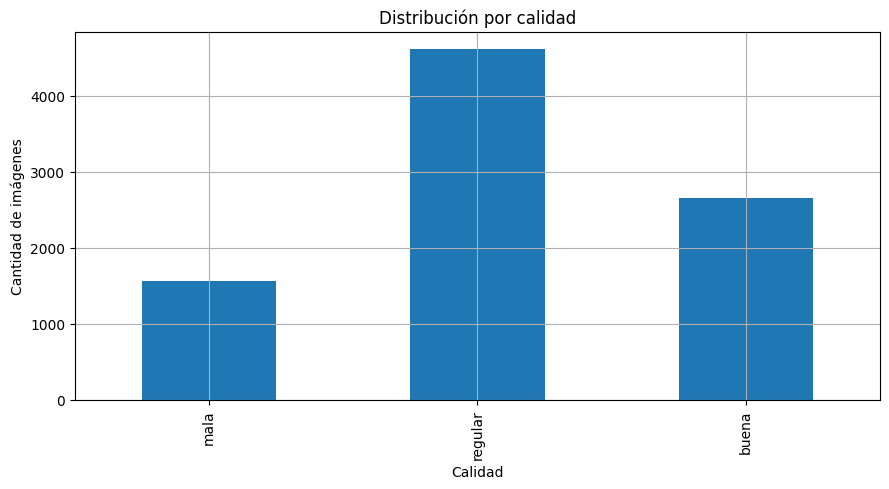

In [7]:
quality_counts = df.groupby("quality_label").size().reindex(QUALITY_LABELS, fill_value=0).reset_index(name="count")
quality_counts["percentage"] = (quality_counts["count"] / len(df) * 100).round(2)
quality_counts["quality_label_es"] = quality_counts["quality_label"].map(QUALITY_LABELS_ES)
quality_counts_path = TABLES_DIR / "02_quality_distribution.csv"
quality_counts.to_csv(quality_counts_path, index=False, encoding="utf-8")

display(quality_counts)
ax = quality_counts.set_index("quality_label_es")["count"].plot(kind="bar")
ax.set_title("Distribución por calidad")
ax.set_xlabel("Calidad")
ax.set_ylabel("Cantidad de imágenes")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_quality_distribution.png", dpi=160)
plt.show()

## 8. Distribución por fuente

Se separa lo público de lo propio para confirmar que el dataset final combina fuentes y no depende de una sola procedencia.

quality_label,bad,regular,good
source,,,
public,0,0,0
own,1564,4613,2659


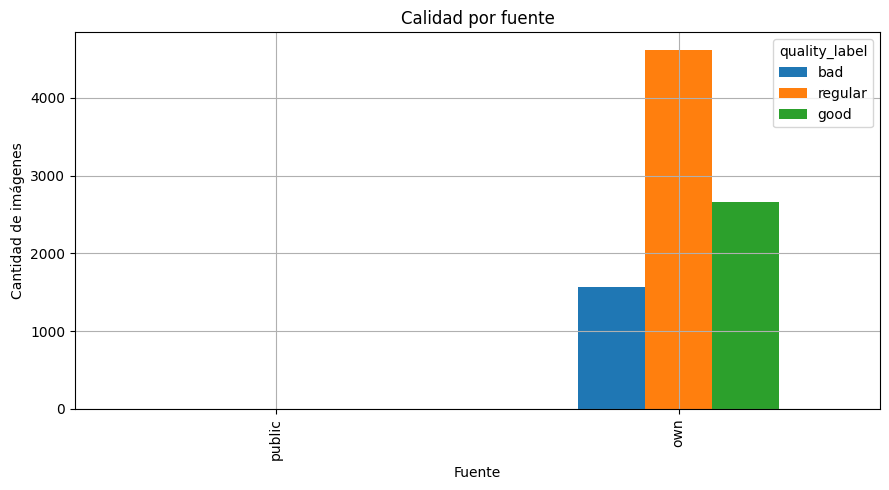

In [8]:
source_quality_table = pd.crosstab(df["source"], df["quality_label"]).reindex(index=SOURCES, columns=QUALITY_LABELS, fill_value=0)
source_quality_path = TABLES_DIR / "03_quality_by_source.csv"
source_quality_table.to_csv(source_quality_path, encoding="utf-8")

display(source_quality_table)
ax = source_quality_table.plot(kind="bar")
ax.set_title("Calidad por fuente")
ax.set_xlabel("Fuente")
ax.set_ylabel("Cantidad de imágenes")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_quality_by_source.png", dpi=160)
plt.show()

## 9. Cobertura por fruta o verdura

Este cruce permite ver qué productos tienen ejemplos suficientes y cuáles deberían reforzarse antes de entrenar modelos.

,product_type,count
5,pomegranate,3314
0,apple,1310
2,guava,1148
1,banana,1141
3,lime,1096
4,orange,827


quality_label,bad,regular,good
product_type,,,
apple,153,890,267
banana,4,936,201
guava,135,813,200
lime,152,744,200
orange,111,510,206
pomegranate,1009,720,1585


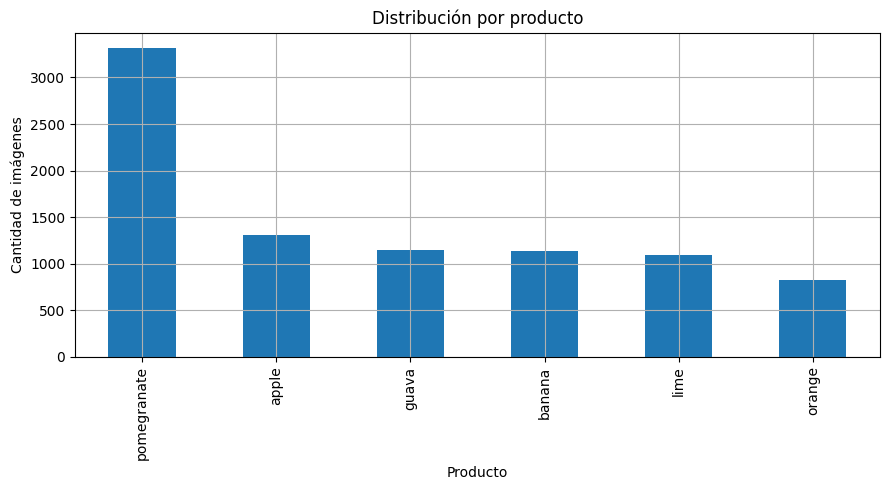

In [9]:
product_counts = df.groupby("product_type").size().reset_index(name="count").sort_values("count", ascending=False)
product_quality_table = pd.crosstab(df["product_type"], df["quality_label"]).reindex(columns=QUALITY_LABELS, fill_value=0)
product_counts_path = TABLES_DIR / "04_product_distribution.csv"
product_quality_path = TABLES_DIR / "05_quality_by_product.csv"
product_counts.to_csv(product_counts_path, index=False, encoding="utf-8")
product_quality_table.to_csv(product_quality_path, encoding="utf-8")

display(product_counts)
display(product_quality_table)
ax = product_counts.set_index("product_type")["count"].plot(kind="bar")
ax.set_title("Distribución por producto")
ax.set_xlabel("Producto")
ax.set_ylabel("Cantidad de imágenes")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_product_distribution.png", dpi=160)
plt.show()

## 10. Revisión de tamaño manual

Si las carpetas o archivos ya incluyen tamaño, se registra. Si no aparece, el Notebook 02 estimará el tamaño relativo desde la imagen.

In [10]:
manual_size_counts = df["size_label_manual"].replace("", np.nan).value_counts(dropna=False).rename_axis("size_label_manual").reset_index(name="count")
manual_size_counts["percentage"] = (manual_size_counts["count"] / len(df) * 100).round(2)
manual_size_path = TABLES_DIR / "06_manual_size_distribution.csv"
manual_size_counts.to_csv(manual_size_path, index=False, encoding="utf-8")

display(manual_size_counts)
print("Imágenes sin tamaño manual:", int((df["size_label_manual"] == "").sum()))

,size_label_manual,count,percentage
0,NaN,8836,100.0


Imágenes sin tamaño manual: 8836


## 11. Dimensiones y condiciones visuales

El EDA no redimensiona imágenes. Solo identifica imágenes no cuadradas, resoluciones bajas o modos de color que deben tratarse en el preprocesamiento.

,count,mean,std,min,25%,50%,75%,max
width,8836.0,1377.153803,1313.860675,13.000000,130.00000,720.0000,3120.000000,4032.000000
height,8836.0,1275.094273,1317.878674,12.000000,122.00000,720.0000,3120.000000,4032.000000
aspect_ratio,8836.0,1.161685,0.402729,0.268817,1.00000,1.0000,1.247423,3.833333
file_size_kb,8836.0,383.103705,455.475351,0.688000,9.02525,132.2345,782.495000,2591.952000


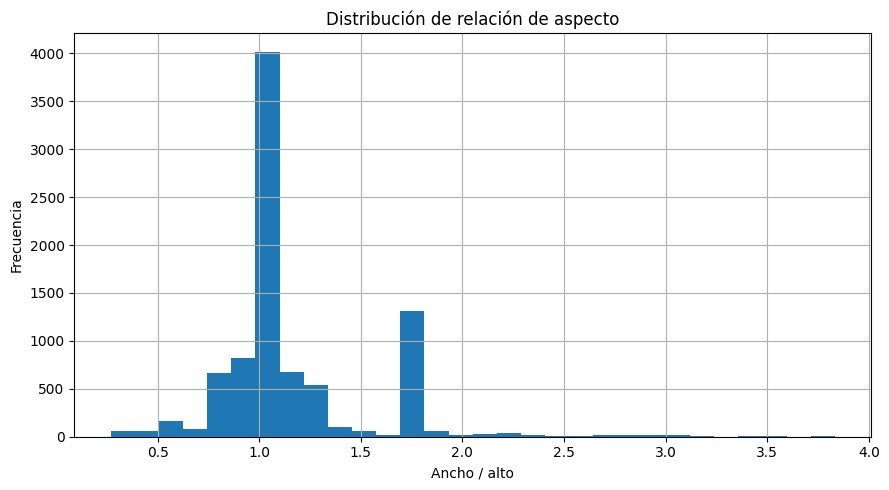

In [11]:
dimension_columns = ["width", "height", "aspect_ratio", "file_size_kb"]
dimension_summary = df[dimension_columns].describe().T
dimension_summary_path = TABLES_DIR / "07_dimension_summary.csv"
dimension_summary.to_csv(dimension_summary_path, encoding="utf-8")

display(dimension_summary)
ax = df["aspect_ratio"].plot(kind="hist", bins=30)
ax.set_title("Distribución de relación de aspecto")
ax.set_xlabel("Ancho / alto")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_aspect_ratio_distribution.png", dpi=160)
plt.show()

## 12. Tabla de revisión antes del preprocesamiento

Se genera una lista de imágenes que conviene revisar. Esto no elimina datos; solo deja una evidencia para tomar decisiones.

In [12]:
review_df = df.copy()
review_df["review_reason"] = ""
review_df.loc[review_df["requires_crop"], "review_reason"] = review_df.loc[review_df["requires_crop"], "review_reason"] + "requires_square_adjustment;"
review_df.loc[~review_df["mode"].isin(["RGB", "RGBA"]), "review_reason"] = review_df.loc[~review_df["mode"].isin(["RGB", "RGBA"]), "review_reason"] + "non_rgb_mode;"
review_df.loc[(review_df["width"] < TARGET_IMAGE_SIZE) | (review_df["height"] < TARGET_IMAGE_SIZE), "review_reason"] = review_df.loc[(review_df["width"] < TARGET_IMAGE_SIZE) | (review_df["height"] < TARGET_IMAGE_SIZE), "review_reason"] + "low_resolution;"
review_df.loc[review_df["size_label_manual"] == "", "review_reason"] = review_df.loc[review_df["size_label_manual"] == "", "review_reason"] + "size_will_be_estimated;"
image_review = review_df[review_df["review_reason"] != ""].copy()
image_review_path = ANNOTATIONS_DIR / "image_review.csv"
image_review.to_csv(image_review_path, index=False, encoding="utf-8")

print("Imágenes marcadas para revisión:", len(image_review))
print("Archivo generado:", image_review_path)
display(image_review[["image_id", "source", "quality_label", "product_type", "size_label_manual", "relative_path", "width", "height", "mode", "review_reason"]].head(30))

Imágenes marcadas para revisión: 8836
Archivo generado: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\data\annotations\image_review.csv


,image_id,source,quality_label,product_type,size_label_manual,relative_path,width,height,mode,review_reason
0,img_bea47128a130,own,bad,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0146.jpg,3024,4032,RGB,requires_square_adjustment;size_will_be_estimated;
1,img_f5608315e131,own,bad,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0148.jpg,3024,4032,RGB,requires_square_adjustment;size_will_be_estimated;
2,img_086a3da0b9de,own,bad,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0150.jpg,3024,4032,RGB,requires_square_adjustment;size_will_be_estimated;
3,img_254e792d4b01,own,bad,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0152.jpg,3024,4032,RGB,requires_square_adjustment;size_will_be_estimated;
4,img_6076a7832114,own,bad,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0154.jpg,3024,4032,RGB,requires_square_adjustment;size_will_be_estimated;
5,img_4baa15523ba0,own,bad,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0156.jpg,3024,4032,RGB,requires_square_adjustment;size_will_be_estimated;
6,img_b9bae0588a87,own,bad,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0158.jpg,3024,4032,RGB,requires_square_adjustment;size_will_be_estimated;
7,img_7073eb96ffb9,own,bad,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0160.jpg,3024,4032,RGB,requires_square_adjustment;size_will_be_estimated;
8,img_66119cc6d85a,own,bad,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0162.jpg,3024,4032,RGB,requires_square_adjustment;size_will_be_estimated;
9,img_11f6d6f88c26,own,bad,apple,,data/raw/propias/Bad_Quality_Fruits/Apple_Bad/IMG-20260603-WA0164.jpg,4032,3024,RGB,requires_square_adjustment;size_will_be_estimated;


## 13. Duplicados exactos

Los duplicados exactos se detectan con el hash del archivo. El Notebook 02 los puede retirar antes de particionar para evitar fuga de datos entre entrenamiento y prueba.

In [13]:
duplicate_images = df[df.duplicated(subset=["image_hash"], keep=False)].sort_values("image_hash")
duplicate_images_path = ANNOTATIONS_DIR / "duplicate_images.csv"
duplicate_images.to_csv(duplicate_images_path, index=False, encoding="utf-8")

print("Duplicados exactos:", len(duplicate_images))
print("Archivo generado:", duplicate_images_path)
display(duplicate_images[["image_hash", "source", "quality_label", "product_type", "relative_path"]].head(30))

Duplicados exactos: 66
Archivo generado: C:\Users\renzi\PycharmProjects\proyecto-final-apo-3\data\annotations\duplicate_images.csv


,image_hash,source,quality_label,product_type,relative_path
4210,01df511a95339c4b955fac68f5f18010,own,good,pomegranate,data/raw/propias/Good_Quality_Fruits/Pomegranate_Good/foto_88.jpg
4078,01df511a95339c4b955fac68f5f18010,own,good,pomegranate,data/raw/propias/Good_Quality_Fruits/Pomegranate_Good/foto_13.jpg
4047,02fc9d70a118404d220fea5a040519ab,own,good,pomegranate,data/raw/propias/Good_Quality_Fruits/Pomegranate_Good/foto_101.jpg
4129,02fc9d70a118404d220fea5a040519ab,own,good,pomegranate,data/raw/propias/Good_Quality_Fruits/Pomegranate_Good/foto_176.jpg
4048,06ceae4aee76b4f4b209812d3fc06cfa,own,good,pomegranate,data/raw/propias/Good_Quality_Fruits/Pomegranate_Good/foto_102.jpg
4130,06ceae4aee76b4f4b209812d3fc06cfa,own,good,pomegranate,data/raw/propias/Good_Quality_Fruits/Pomegranate_Good/foto_177.jpg
4205,078460c9aa1471adf26c44cce89badbf,own,good,pomegranate,data/raw/propias/Good_Quality_Fruits/Pomegranate_Good/foto_83.jpg
4201,078460c9aa1471adf26c44cce89badbf,own,good,pomegranate,data/raw/propias/Good_Quality_Fruits/Pomegranate_Good/foto_8.jpg
4219,16bb0b8bbb311d1689543a2291631581,own,good,pomegranate,data/raw/propias/Good_Quality_Fruits/Pomegranate_Good/foto_96.jpg
4124,16bb0b8bbb311d1689543a2291631581,own,good,pomegranate,data/raw/propias/Good_Quality_Fruits/Pomegranate_Good/foto_171.jpg


## 14. Muestra visual

Se observa una muestra pequeña para verificar que la etiqueta registrada sí coincide con lo que aparece en la imagen.

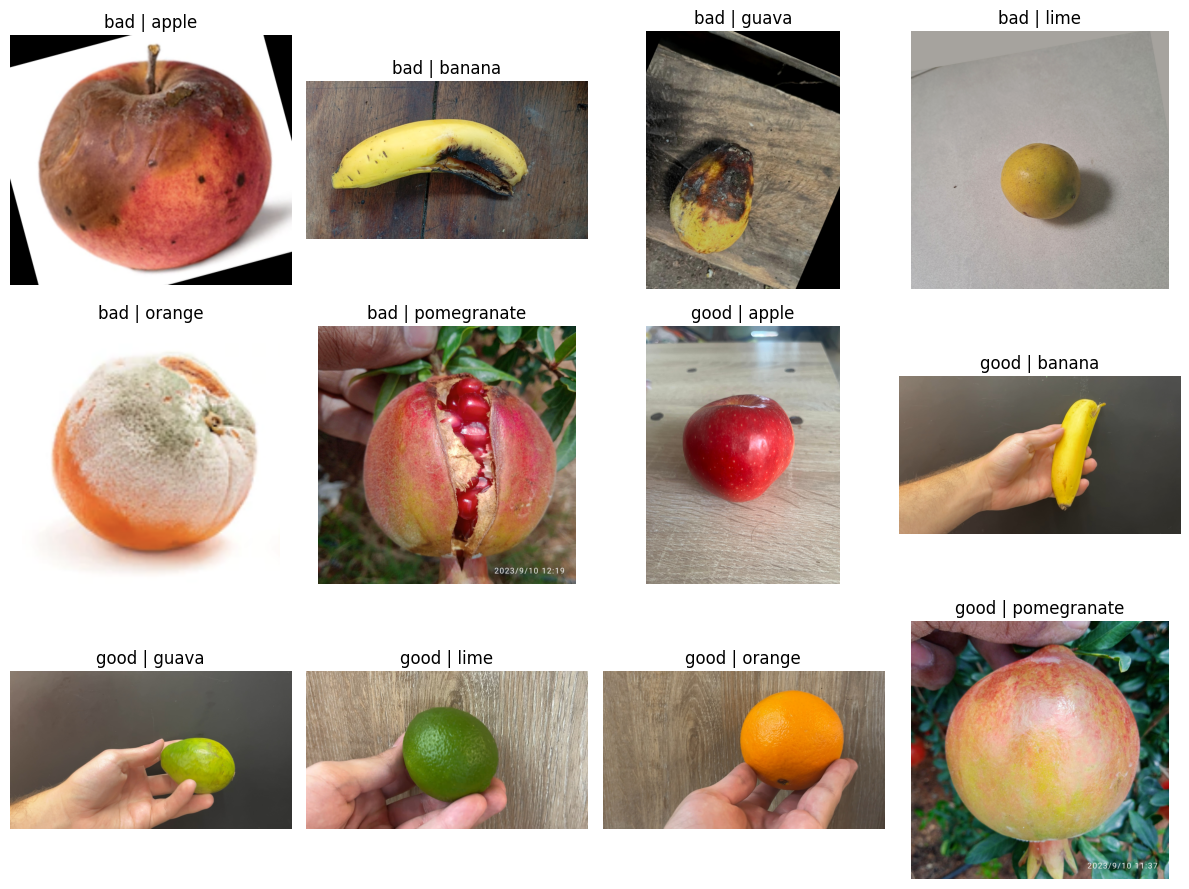

In [14]:
def show_sample_grid(data, n=12):
    if data.empty:
        print("No hay imágenes para visualizar.")
        return

    grouped = data.groupby(["quality_label", "product_type"], group_keys=False)
    sample = grouped.sample(n=1, random_state=RANDOM_STATE) if len(grouped) > 0 else data.sample(min(n, len(data)), random_state=RANDOM_STATE)
    sample = sample.head(n).reset_index(drop=True)
    cols = 4
    rows = int(np.ceil(len(sample) / cols))
    plt.figure(figsize=(cols * 3, rows * 3))

    for index, row in sample.iterrows():
        image_path = PROJECT_ROOT / row["relative_path"]
        image = Image.open(image_path)
        image = ImageOps.exif_transpose(image)
        plt.subplot(rows, cols, index + 1)
        plt.imshow(image)
        plt.title(f"{row['quality_label']} | {row['product_type']}")
        plt.axis("off")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "06_image_sample.png", dpi=160)
    plt.show()


show_sample_grid(df)

## 15. Salidas generadas

Estas son las salidas que quedan listas para el Notebook 02.

In [15]:
outputs = pd.DataFrame({
    "archivo": [
        "data/annotations/labels.csv",
        "data/annotations/image_review.csv",
        "data/annotations/image_invalid_paths.csv",
        "data/annotations/duplicate_images.csv",
        "data/annotations/data_dictionary.md",
        "results/tables/01_folder_inventory.csv",
        "results/tables/02_quality_distribution.csv",
        "results/tables/03_quality_by_source.csv",
        "results/tables/04_product_distribution.csv",
        "results/tables/05_quality_by_product.csv",
        "results/tables/06_manual_size_distribution.csv",
        "results/tables/07_dimension_summary.csv"
    ],
    "uso": [
        "Entrada principal para limpieza, tamaño y partición",
        "Imágenes que requieren revisión antes del preprocesamiento",
        "Imágenes que no pudieron entrar al dataset válido",
        "Duplicados exactos detectados por hash",
        "Contrato de columnas creado por este notebook",
        "Inventario de raíces de datos",
        "Balance de calidad",
        "Cruce entre fuente y calidad",
        "Cobertura por fruta o verdura",
        "Cruce entre producto y calidad",
        "Tamaño manual disponible en nombres o carpetas",
        "Resumen de dimensiones originales"
    ]
})

display(outputs)

,archivo,uso
0,data/annotations/labels.csv,"Entrada principal para limpieza, tamaño y partición"
1,data/annotations/image_review.csv,Imágenes que requieren revisión antes del preprocesamiento
2,data/annotations/image_invalid_paths.csv,Imágenes que no pudieron entrar al dataset válido
3,data/annotations/duplicate_images.csv,Duplicados exactos detectados por hash
4,data/annotations/data_dictionary.md,Contrato de columnas creado por este notebook
5,results/tables/01_folder_inventory.csv,Inventario de raíces de datos
6,results/tables/02_quality_distribution.csv,Balance de calidad
7,results/tables/03_quality_by_source.csv,Cruce entre fuente y calidad
8,results/tables/04_product_distribution.csv,Cobertura por fruta o verdura
9,results/tables/05_quality_by_product.csv,Cruce entre producto y calidad
